In [1]:
from DeepTemporalClustering import DTC
from sklearn.preprocessing import StandardScaler
from tslearn.datasets import UCR_UEA_datasets
from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf

In [2]:
from sklearn.model_selection import train_test_split

X_train_full, y_train_full, X_test, y_test = UCR_UEA_datasets().load_dataset('CBF')


In [3]:
train_size = int(len(X_train_full) * 0.8)

In [4]:
X_train = X_train_full[:train_size]
y_train = y_train_full[:train_size]

X_val = X_train_full[train_size:]
y_val = y_train_full[train_size:]

In [5]:
print(f"X_train shape: {X_train.shape}\ny_train shape: {y_train.shape}\nX_val shape: {X_val.shape}\ny_val shape: {y_val.shape}")

X_train shape: (24, 128, 1)
y_train shape: (24,)
X_val shape: (6, 128, 1)
y_val shape: (6,)


In [6]:
modelo = DTC(n_clusters = 3, input_dim = X_train.shape[2], timesteps = X_train.shape[1],pool_size = 2)
modelo.initialize()
modelo.fit(X_train,y_train,X_val,y_val,n_clusters = 3)

Autoencoder was not pre-trained!
Extraindo do características do espaço latente: 
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
Treinando Kmeans com 3 clusters...
[Train] Acc=0.7083, Pur=0.7083, NMI=0.4227, ARI=0.2554
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
[Val]   Acc=0.6667, Pur=0.6667, NMI=0.4078, ARI=0.1667
Done.


array([1, 1, 0, 0, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 0, 2, 2,
       1, 1], dtype=int32)

In [7]:
encoded = modelo.encode(X_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


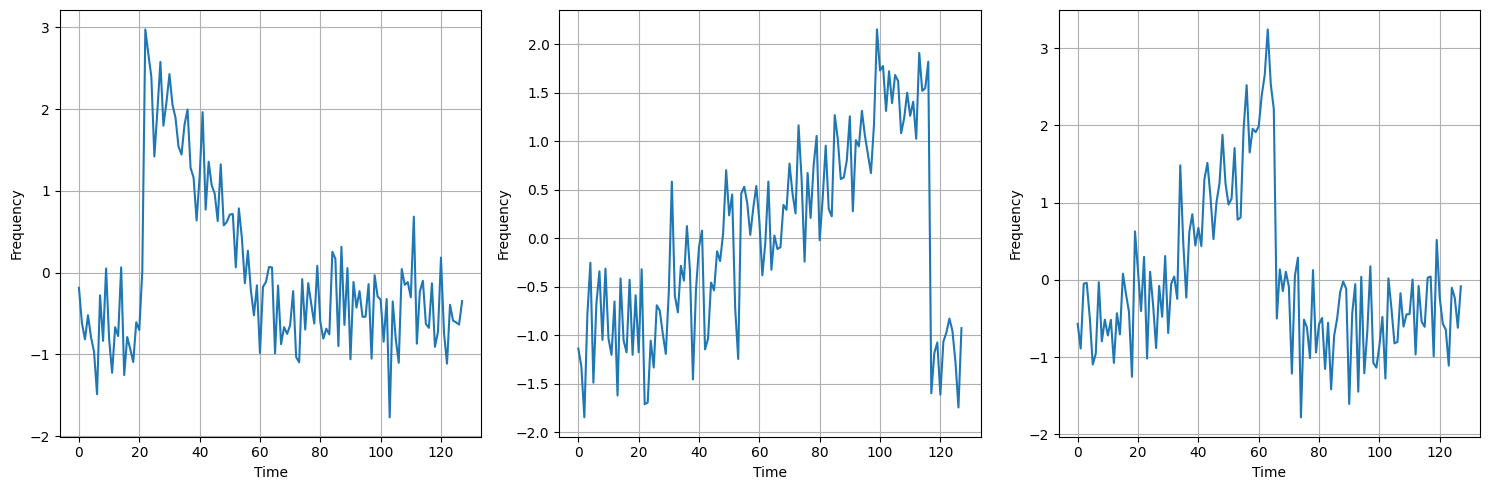

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = [3, 4, 5]

for i, idx in enumerate(indices):
    axes[i].plot(X_train[idx])
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)

plt.tight_layout()
plt.savefig("fig/Série a ser analisada")
plt.show()

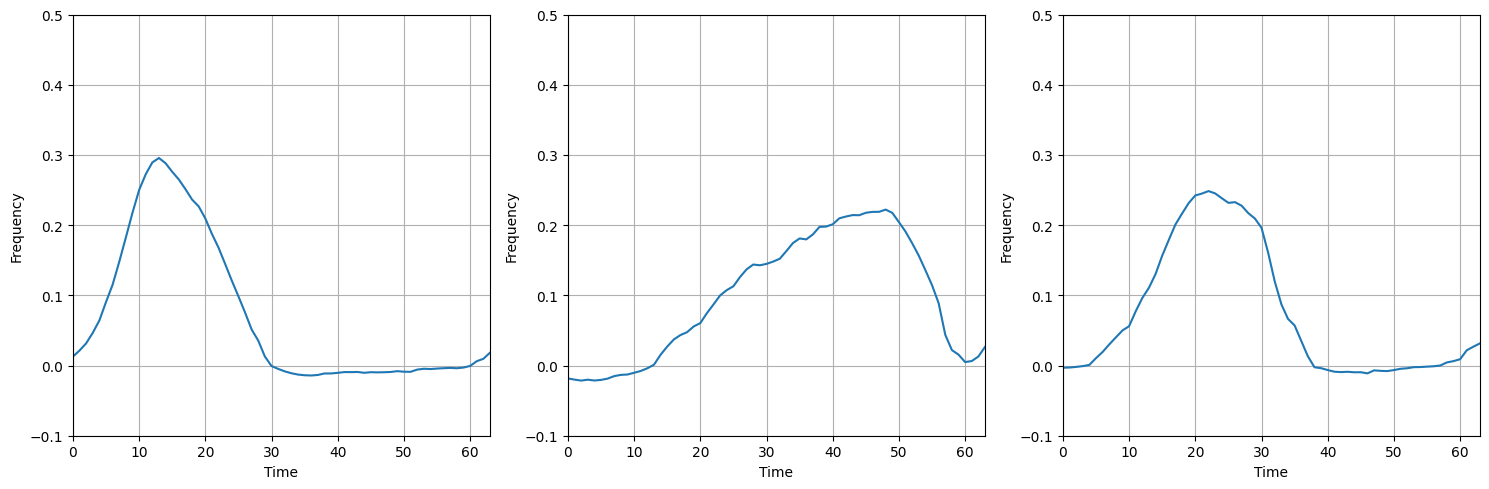

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = [3, 4, 5]

for i, idx in enumerate(indices):
    axes[i].plot(encoded[idx])
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)
    axes[i].set_xlim(0, X_train.shape[1] / modelo.pool_size - 1)
    axes[i].set_ylim(-0.1, 0.5)

plt.tight_layout()
plt.savefig("fig/Representação no espaço latente")
plt.show()

